# Home Credit Default Risk – Exploratory Data Analysis
## 1. Objective
Home Credit aims to predict whether a loan applicant will default.

This analysis explores:
- customer demographics
- financial characteristics
- credit history
- repayment behavior

Goal: identify **risk indicators correlated with loan default**.

### 2. Imports and Plot Configuration

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

import warnings
warnings.filterwarnings("ignore")

### 3. Load Data

In [2]:
base_path="./data/"
train = pd.read_csv(f"{base_path}application_train.csv")
bureau = pd.read_csv(f"{base_path}bureau.csv")
previous = pd.read_csv(f"{base_path}previous_application.csv")
installments = pd.read_csv(f"{base_path}installments_payments.csv")

### 4. Dataset Overview

In [3]:
train.shape

(307511, 122)

In [4]:
train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


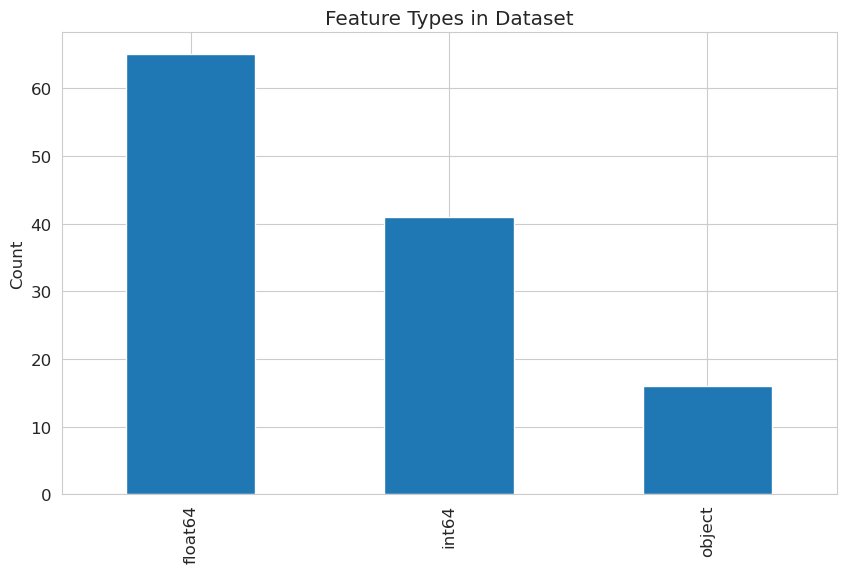

In [5]:
train.dtypes.value_counts().plot(kind="bar")

plt.title("Feature Types in Dataset")
plt.ylabel("Count")
plt.show()

### 5. Target Variable Analysis

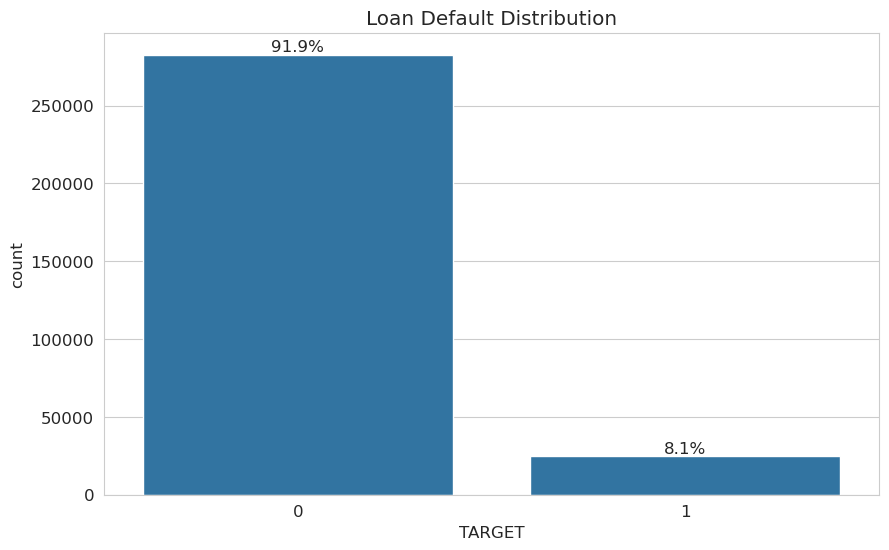

In [6]:
ax = sns.countplot(x="TARGET", data=train)
total = len(train)
# Adds percentages on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{(x/total)*100:0.1f}%')

plt.title("Loan Default Distribution")
plt.show()


Default rate ≈ 8.1%  
Strong class imbalance

### 6. Missing Value Analysis

In [7]:
missing = (train.isnull().mean() * 100).sort_values(ascending=False)
print(missing.head(20))


COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64


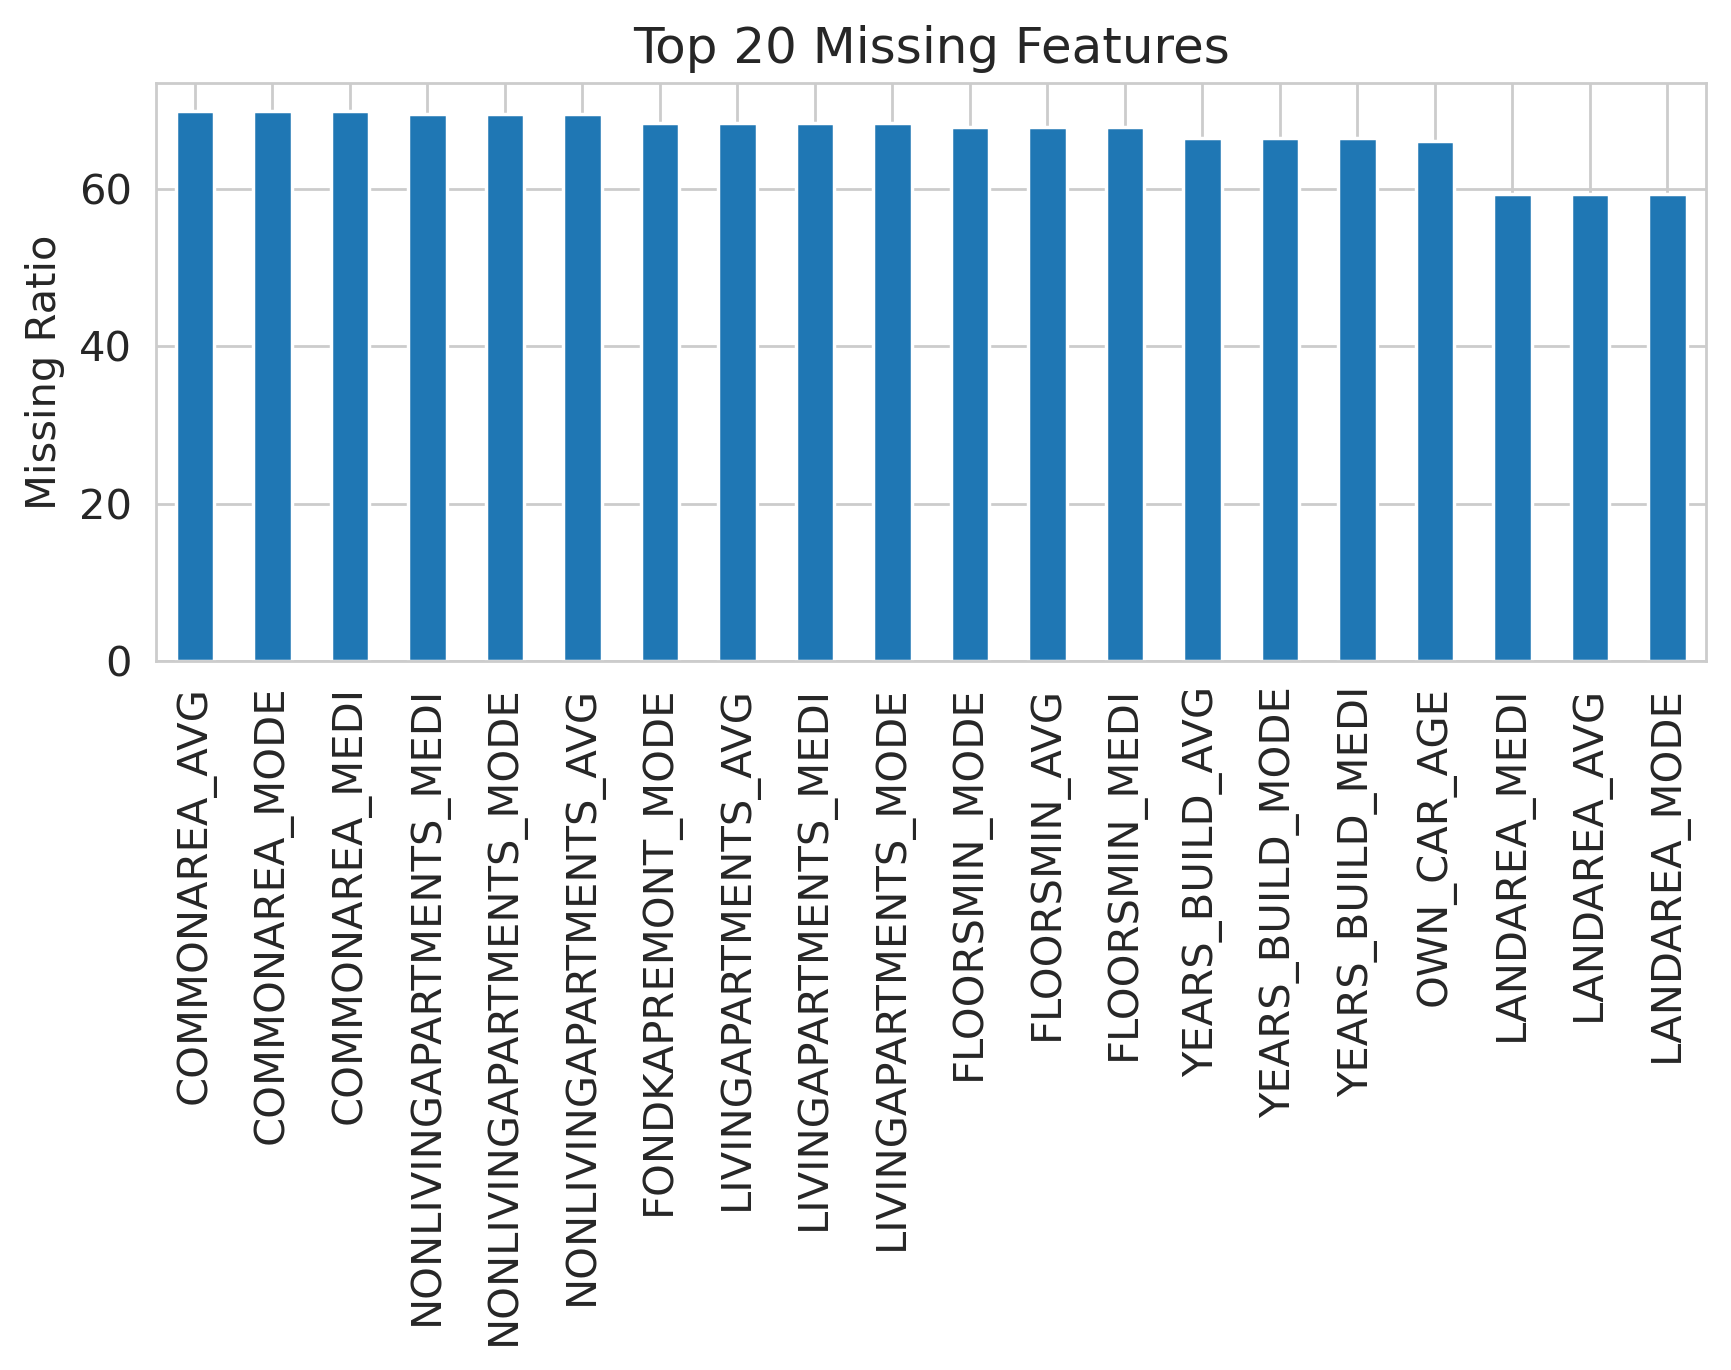

In [8]:
plt.figure(figsize=(8,3), dpi=250)
missing.head(20).plot(kind="bar")

plt.title("Top 20 Missing Features")
plt.ylabel("Missing Ratio")
plt.show()

#### Missing Data Observations

The features with the highest missing values are primarily related to
housing characteristics and building attributes.

Most of these variables have missing rates above 60%, suggesting that
housing information is not consistently available for many applicants.

Additionally, several housing attributes appear in three forms
(AVG, MEDI, MODE), representing different statistical summaries of
the same variable.

Given the high missing rates, these variables may require careful
handling during feature engineering and model development.

### 7. Age Risk Analysis

In [9]:
train["AGE"] = -train["DAYS_BIRTH"] / 365

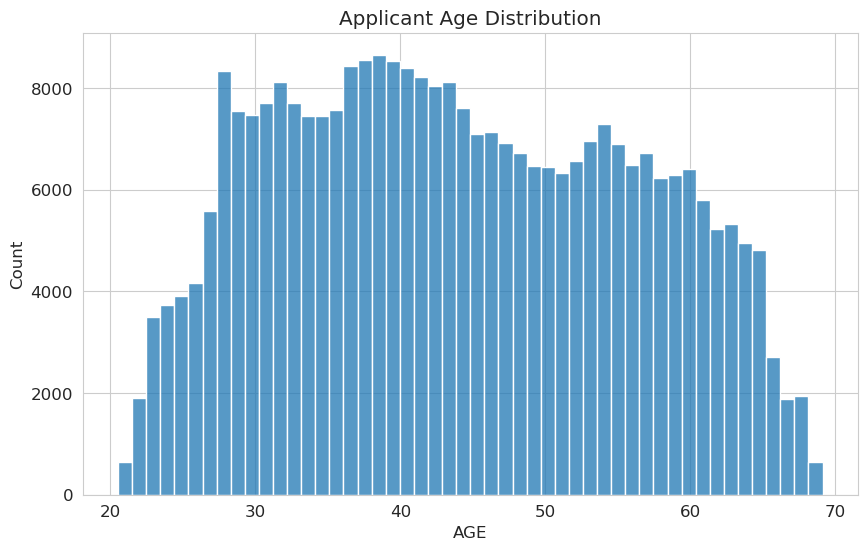

In [10]:
sns.histplot(train["AGE"], bins=50)

plt.title("Applicant Age Distribution")
plt.show()

#### Age Distribution of Loan Applicants

The majority of applicants fall between **30 and 45 years of age**, with a peak around **35–40 years**. 

Very young applicants (below ~25) and older applicants (above ~60) are less common in the dataset.

This suggests that Home Credit primarily serves **working-age individuals**, which aligns with typical lending patterns where stable income and employment are required.

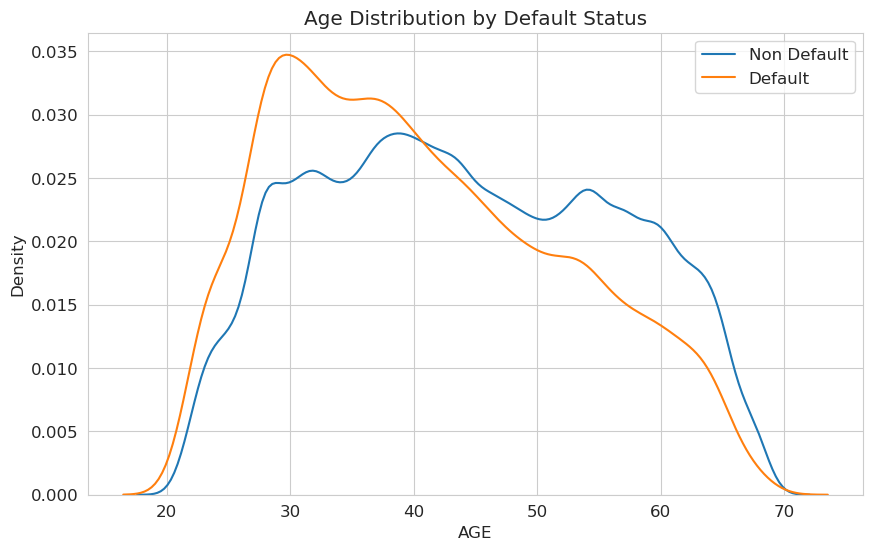

In [11]:
sns.kdeplot(train.loc[train.TARGET==0,"AGE"], label="Non Default")
sns.kdeplot(train.loc[train.TARGET==1,"AGE"], label="Default")

plt.title("Age Distribution by Default Status")
plt.legend()
plt.show()

#### Age and Default Risk

Comparing the age distributions of defaulters and non-defaulters reveals a clear pattern.

Borrowers who default tend to be **younger on average**, with a higher concentration in the **25–35 age range**. 

In contrast, **older applicants (40+) are more likely to repay their loans successfully**.

This may reflect greater financial stability, income consistency, and credit experience among older borrowers.

### 8. Income Analysis

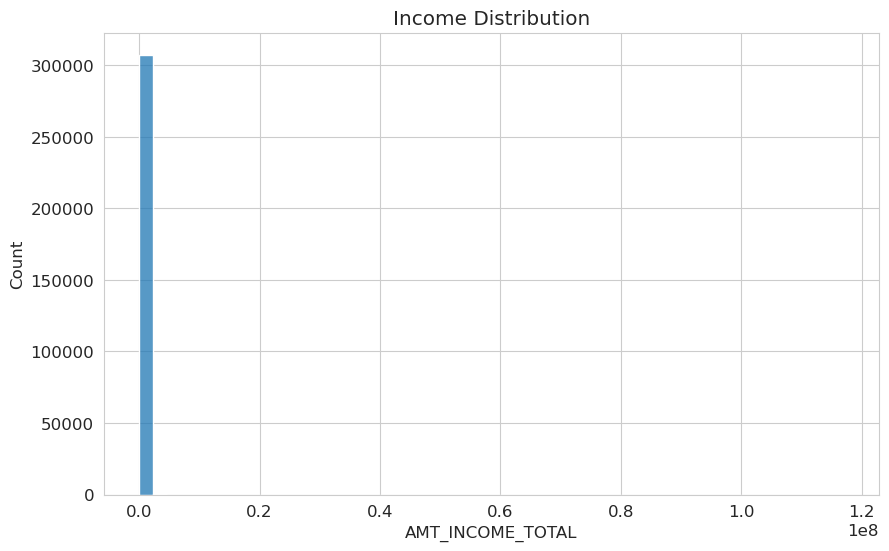

In [12]:
sns.histplot(train["AMT_INCOME_TOTAL"], bins=50)

plt.title("Income Distribution")
plt.show()

#### Income Distribution

The raw income distribution appears heavily compressed due to the presence of extreme income outliers. 
A small number of applicants report very large incomes (tens of millions), which stretches the axis and makes the majority of values difficult to observe.

Most applicants have incomes far below these extreme values, indicating that the dataset contains several high-income outliers that distort the distribution.

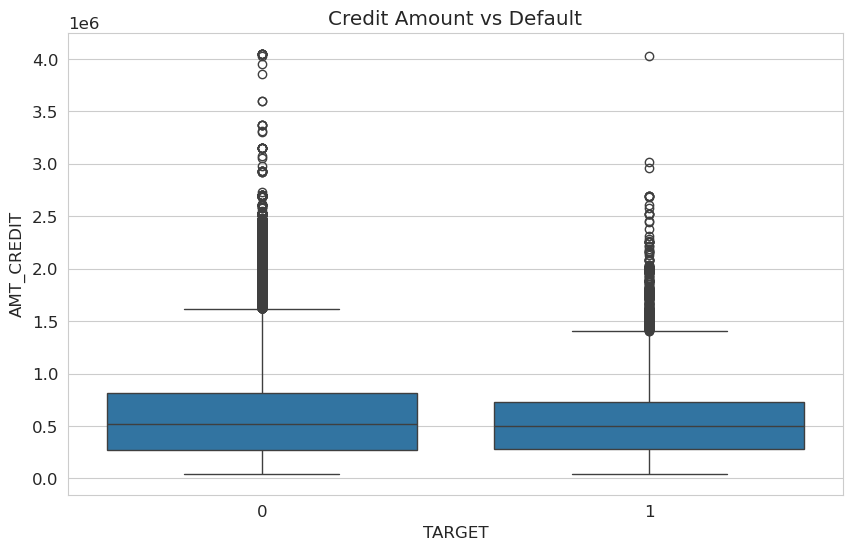

In [13]:
sns.boxplot(x="TARGET", y="AMT_CREDIT", data=train)

plt.title("Credit Amount vs Default")
plt.show()

#### Credit Amount and Default Risk

The distribution of credit amounts is broadly similar between defaulters and non-defaulters.

While the median loan size is comparable for both groups, defaulters show a slightly wider spread of credit values and include several large loan outliers.

This suggests that credit amount alone may not be a strong predictor of default risk and may need to be combined with other financial variables.

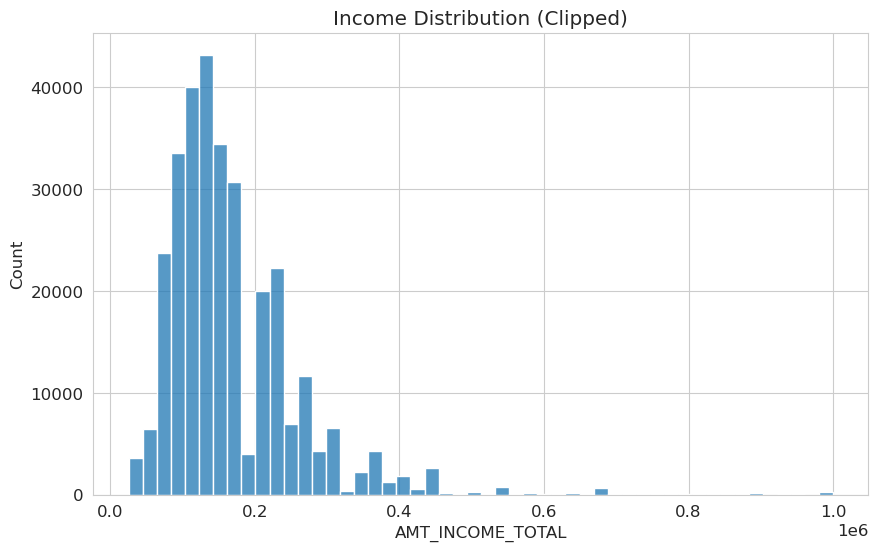

In [14]:
sns.histplot(train["AMT_INCOME_TOTAL"].clip(upper=1000000), bins=50)

plt.title("Income Distribution (Clipped)")
plt.show()

#### Income Distribution (After Removing Outliers)

After clipping extreme income values, the distribution reveals that most applicants earn between approximately 50,000 and 300,000.

The distribution remains right-skewed, with a larger concentration of borrowers in the lower and middle income ranges and fewer high-income applicants.

This suggests that Home Credit primarily serves borrowers in the middle-income segment.

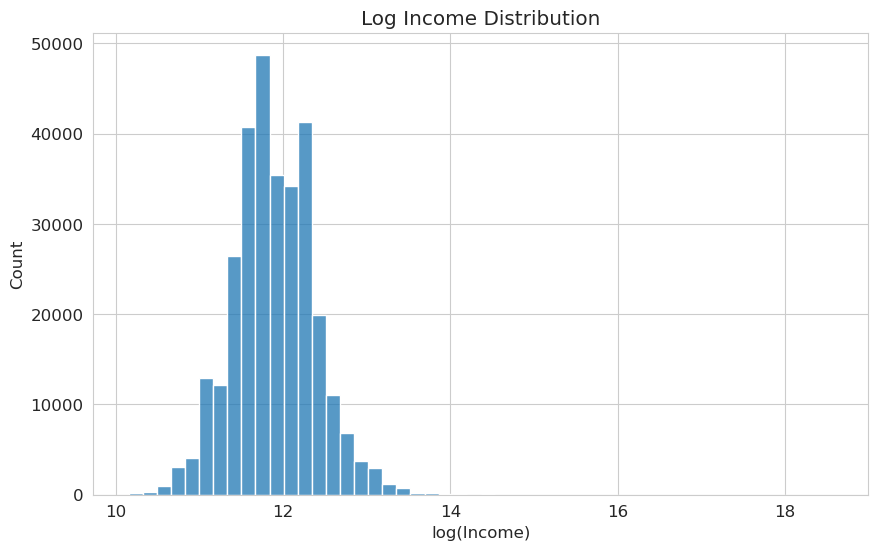

In [15]:
sns.histplot(np.log1p(train["AMT_INCOME_TOTAL"]), bins=50)

plt.title("Log Income Distribution")
plt.xlabel("log(Income)")
plt.show()

#### Log-Transformed Income Distribution

Applying a logarithmic transformation reduces the skewness of the income distribution and produces a more symmetric shape.

This indicates that the original income data is highly skewed with extreme values, and log transformation is useful for stabilizing the distribution for further analysis or modeling.

#### Financial Characteristics of Borrowers

Income data shows strong skewness due to extreme high-income outliers. 
After adjusting for these outliers, the majority of applicants appear to belong to middle-income groups.

Credit amounts alone do not strongly differentiate defaulters from non-defaulters, suggesting that loan size must be evaluated relative to borrower income to better understand financial risk.

In [16]:
# train["CREDIT_INCOME_RATIO"] = (
#     train["AMT_CREDIT"] / train["AMT_INCOME_TOTAL"]
# )

### 9. Credit Amount Analysis

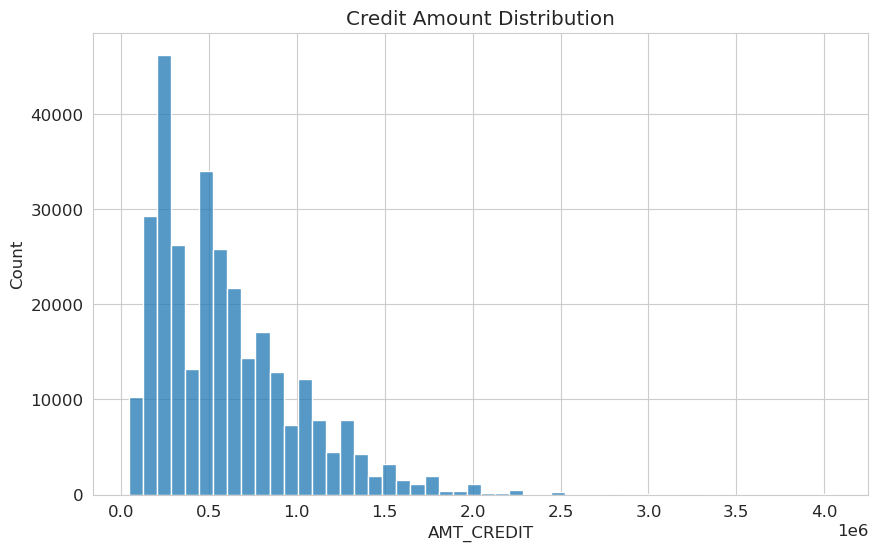

In [17]:
sns.histplot(train["AMT_CREDIT"], bins=50)

plt.title("Credit Amount Distribution")
plt.show()

#### Credit Amount Distribution

The distribution of loan credit amounts is strongly right-skewed.  
Most applicants receive loans between approximately **200,000 and 800,000**, with fewer applicants receiving very large loans above 1,500,000.

This suggests that the majority of loans issued by Home Credit fall within a moderate range, while very large loans are relatively rare.

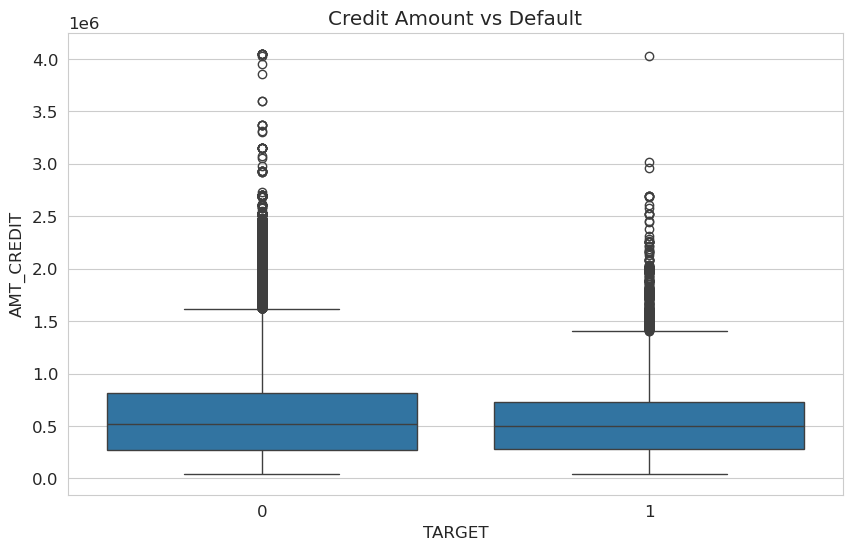

In [18]:
sns.boxplot(x="TARGET", y="AMT_CREDIT", data=train)

plt.title("Credit Amount vs Default")
plt.show()

#### Credit Amount and Default Risk

The boxplot shows that the median credit amount is very similar for both defaulters and non-defaulters.

While both groups contain large loan outliers, the overall distributions overlap significantly. This indicates that **loan size alone is not a strong indicator of default risk**.

Instead, credit risk is likely influenced by the borrower's ability to repay the loan relative to their financial capacity.

#### Credit vs Financial Capacity

Although credit amounts vary across applicants, the similarity in distributions between defaulters and non-defaulters suggests that **loan size alone does not determine default risk**.

A more meaningful measure of financial risk is the **ratio of credit amount to borrower income**, which reflects the repayment burden placed on the borrower.

### 10. Credit to Income Ratio (Important Risk Feature)

In [19]:
train["CREDIT_INCOME_RATIO"] = train["AMT_CREDIT"] / train["AMT_INCOME_TOTAL"]

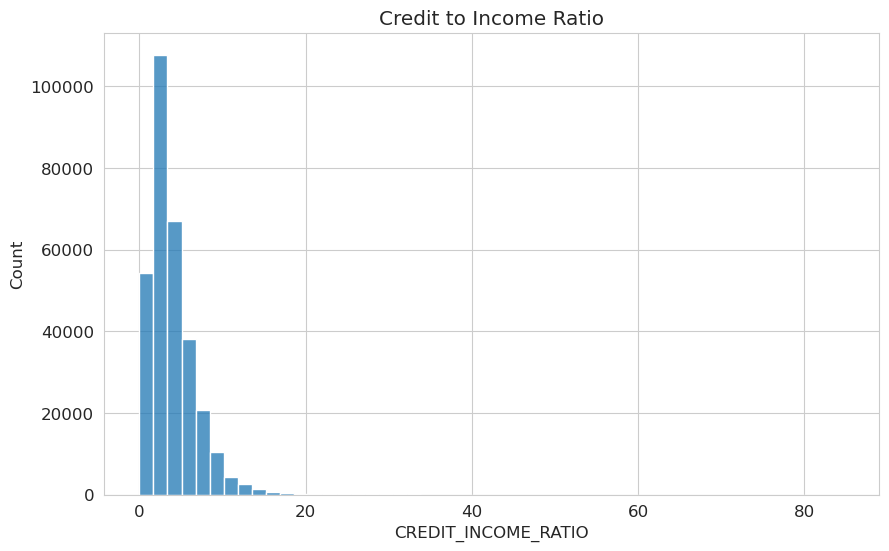

In [20]:
sns.histplot(train["CREDIT_INCOME_RATIO"], bins=50)

plt.title("Credit to Income Ratio")
plt.show()

#### Credit-to-Income Ratio Distribution

The credit-to-income ratio measures how large a loan is relative to the borrower's income. 

Most applicants have ratios between **1 and 5**, meaning the loan amount is roughly one to five times their annual income.

The distribution is right-skewed, indicating that while most borrowers take loans within a reasonable range relative to income, a small number of applicants take loans that are significantly larger compared to their earnings.

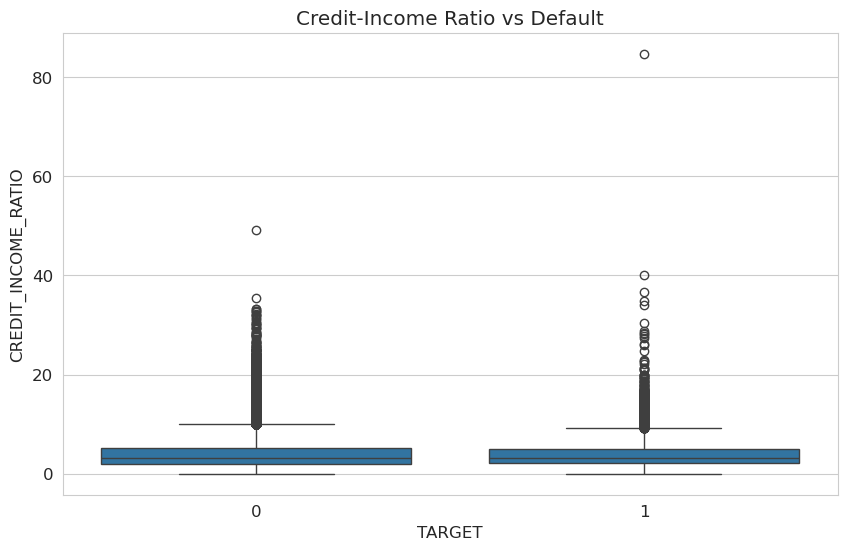

In [21]:
sns.boxplot(x="TARGET", y="CREDIT_INCOME_RATIO", data=train)

plt.title("Credit-Income Ratio vs Default")
plt.show()

#### Credit-to-Income Ratio and Default Risk

Comparing the distributions of credit-to-income ratios between defaulters and non-defaulters shows that defaulters generally have **higher ratios on average**.

Borrowers with larger loans relative to their income appear to have **greater financial risk**, as they may face greater difficulty repaying their loans.

The presence of extreme ratio values among defaulters suggests that excessive borrowing relative to income may increase the likelihood of default.


#### Financial Risk Indicator

The credit-to-income ratio provides a better measure of borrower risk than credit amount or income alone.

A higher ratio indicates that the borrower has taken a loan that represents a large proportion of their income, which increases financial pressure and the probability of default.

### 11. Employment Duration

In [22]:
np.sort(train["DAYS_EMPLOYED"].unique(), )[::-1]

array([365243,      0,     -1, ..., -17546, -17583, -17912],
      shape=(12574,))

In [23]:
train["DAYS_EMPLOYED"].replace(365243, np.nan, inplace=True)

train["EMPLOYMENT_YEARS"] = -train["DAYS_EMPLOYED"] / 365

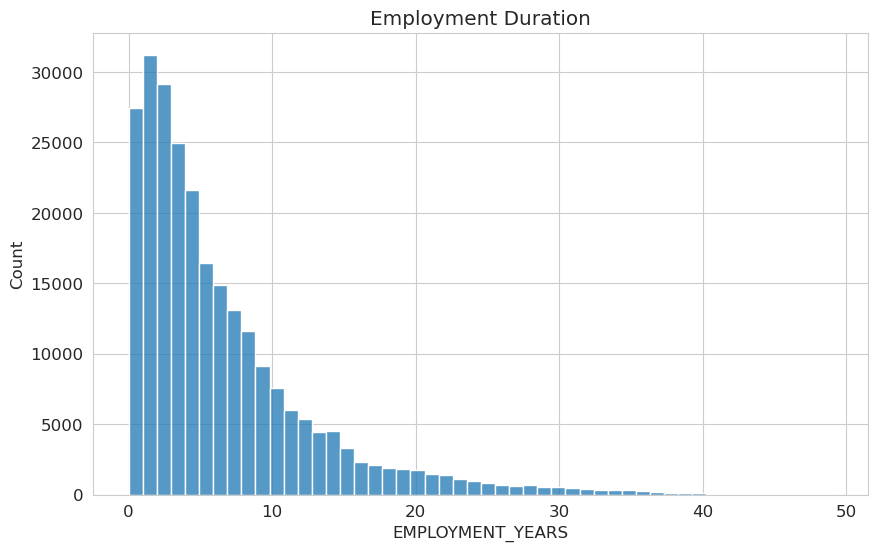

In [24]:
sns.histplot(train["EMPLOYMENT_YEARS"], bins=50)

plt.title("Employment Duration")
plt.show()

#### Employment Duration Distribution

The distribution of employment duration is right-skewed, with the majority of applicants having fewer than 10 years of employment history.

Most borrowers appear to have relatively short employment tenures, while long employment histories above 20 years are less common. This suggests that the applicant pool largely consists of individuals in the early to middle stages of their careers.

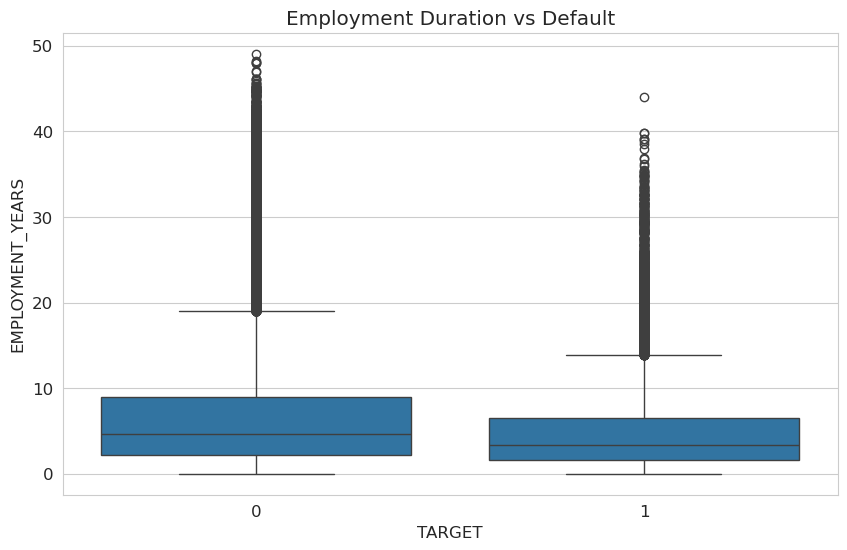

In [25]:
sns.boxplot(x="TARGET", y="EMPLOYMENT_YEARS", data=train)

plt.title("Employment Duration vs Default")
plt.show()

#### Employment Duration and Default Risk

Comparing employment duration across default groups shows that borrowers who repay their loans successfully tend to have slightly longer employment histories.

Defaulters generally exhibit shorter employment durations, which may indicate lower job stability or less consistent income. Longer employment history may therefore serve as an indicator of financial stability and reduced credit risk.

#### Employment Stability as a Risk Indicator

Employment duration is an important indicator of financial stability. Borrowers with longer employment histories are more likely to have stable income sources and stronger repayment capacity.

In contrast, applicants with very short employment histories may face greater financial uncertainty, which could increase the probability of loan default.

### 12. External Risk Scores (Very Important)

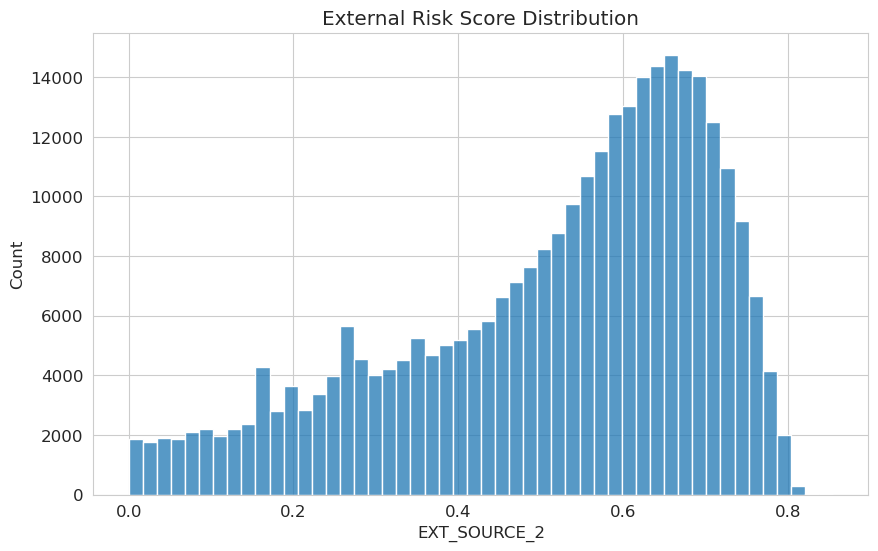

In [26]:
sns.histplot(train["EXT_SOURCE_2"], bins=50)

plt.title("External Risk Score Distribution")
plt.show()

#### External Risk Score Distribution

The external risk score (EXT_SOURCE_2) ranges approximately between 0 and 0.85. 
Most applicants have values between **0.5 and 0.7**, indicating moderate to high creditworthiness according to external data sources.

This feature likely represents a normalized external credit scoring metric derived from historical financial behavior.

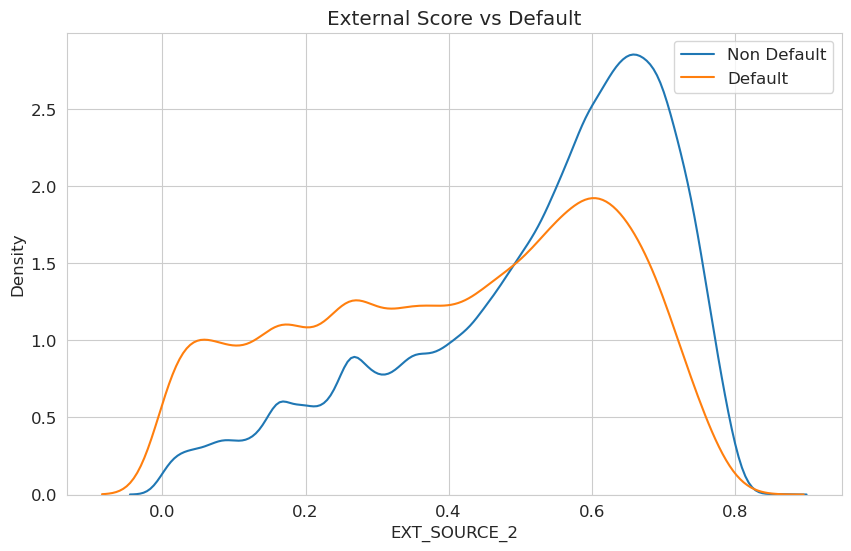

In [27]:
sns.kdeplot(train.loc[train.TARGET==0,"EXT_SOURCE_2"], label="Non Default")
sns.kdeplot(train.loc[train.TARGET==1,"EXT_SOURCE_2"], label="Default")

plt.legend()
plt.title("External Score vs Default")
plt.show()

#### External Risk Score and Default Probability

The external risk score shows a strong relationship with loan default behavior.

Borrowers who default tend to have **lower external scores**, while applicants who successfully repay their loans generally have **higher scores**.

This clear separation between the distributions suggests that EXT_SOURCE_2 is a highly informative feature for predicting credit risk.

### 13. Bureau Credit History Analysis

In [28]:
bureau_counts = bureau.groupby("SK_ID_CURR").size()

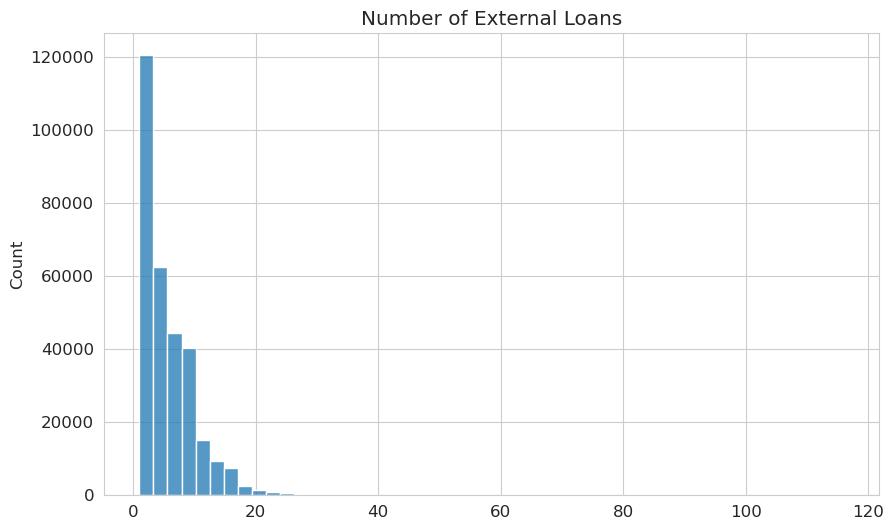

In [29]:
sns.histplot(bureau_counts, bins=50)

plt.title("Number of External Loans")
plt.show()

#### External Credit History

The distribution of external loans is highly right-skewed. Most applicants have fewer than five previous loans recorded in the external credit bureau data, indicating limited prior borrowing history.

However, a smaller group of applicants have significantly larger numbers of previous loans, suggesting extensive credit usage across multiple institutions.

### 14. Previous Loan Amounts

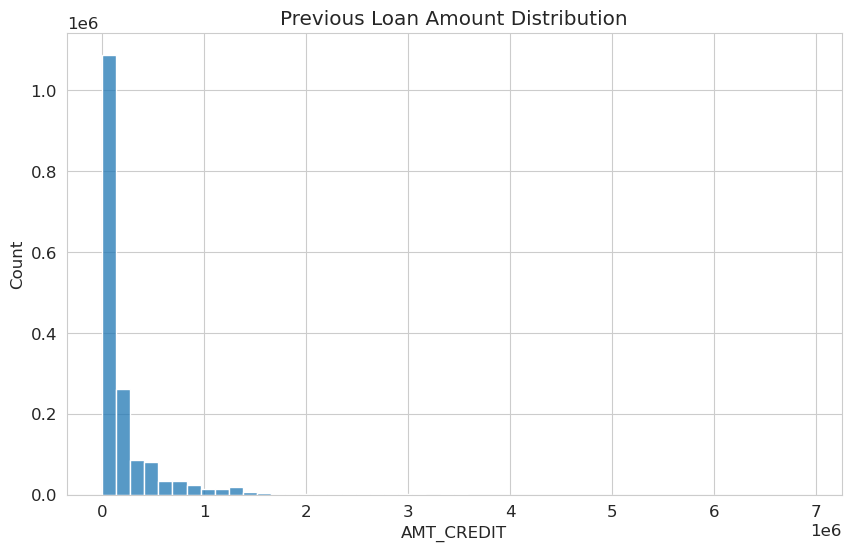

In [30]:
sns.histplot(previous["AMT_CREDIT"], bins=50)

plt.title("Previous Loan Amount Distribution")
plt.show()

#### Previous Loan Amount Distribution

The distribution of previous loan amounts is strongly right-skewed, with the majority of previous loans falling below approximately 200,000.

Only a small proportion of loans exceed 1,000,000, indicating that most historical loans issued by the lender are relatively small. 

This pattern suggests that borrowers typically begin with smaller loan amounts and may gradually access larger credit amounts over time as their creditworthiness is established.

Borrowers with multiple previous loans may exhibit established credit histories. However, larger previous loan amounts could also indicate higher financial exposure, which may influence repayment behavior in future credit applications.

### 15. Installment Payment Behavior

In [31]:
installments["PAYMENT_DELAY"] = (
installments["DAYS_ENTRY_PAYMENT"] -
installments["DAYS_INSTALMENT"]
)

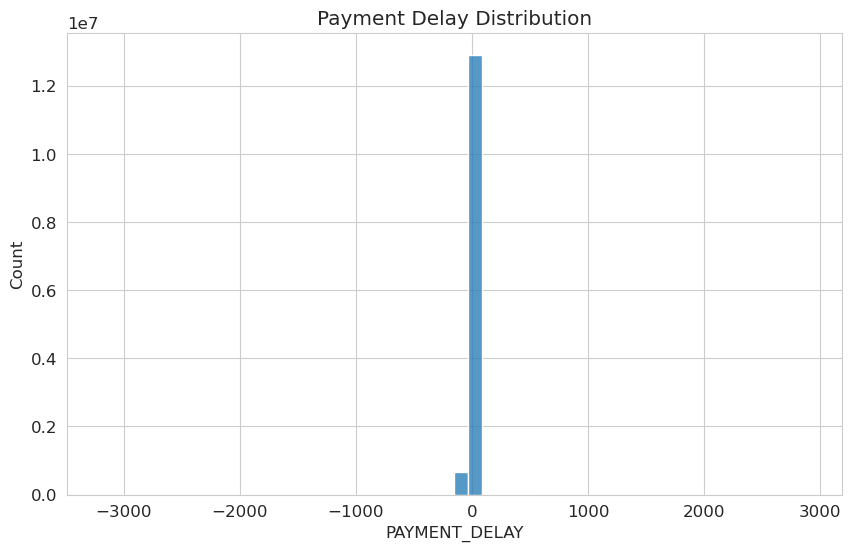

In [32]:
sns.histplot(installments["PAYMENT_DELAY"], bins=50)

plt.title("Payment Delay Distribution")
plt.show()

#### Installment Payment Delay

The payment delay distribution shows a large concentration of values around zero, indicating that most borrowers make payments close to the scheduled installment date.

Negative delay values represent payments made before the due date, while positive values indicate late payments.

Although extreme delays exist in the dataset, the majority of payments occur within a relatively small window around the due date.

    Frequent late payments may indicate financial distress and reduced repayment reliability. Borrowers who consistently pay installments late are more likely to experience repayment difficulties in future loans.

### 16. Correlation Analysis

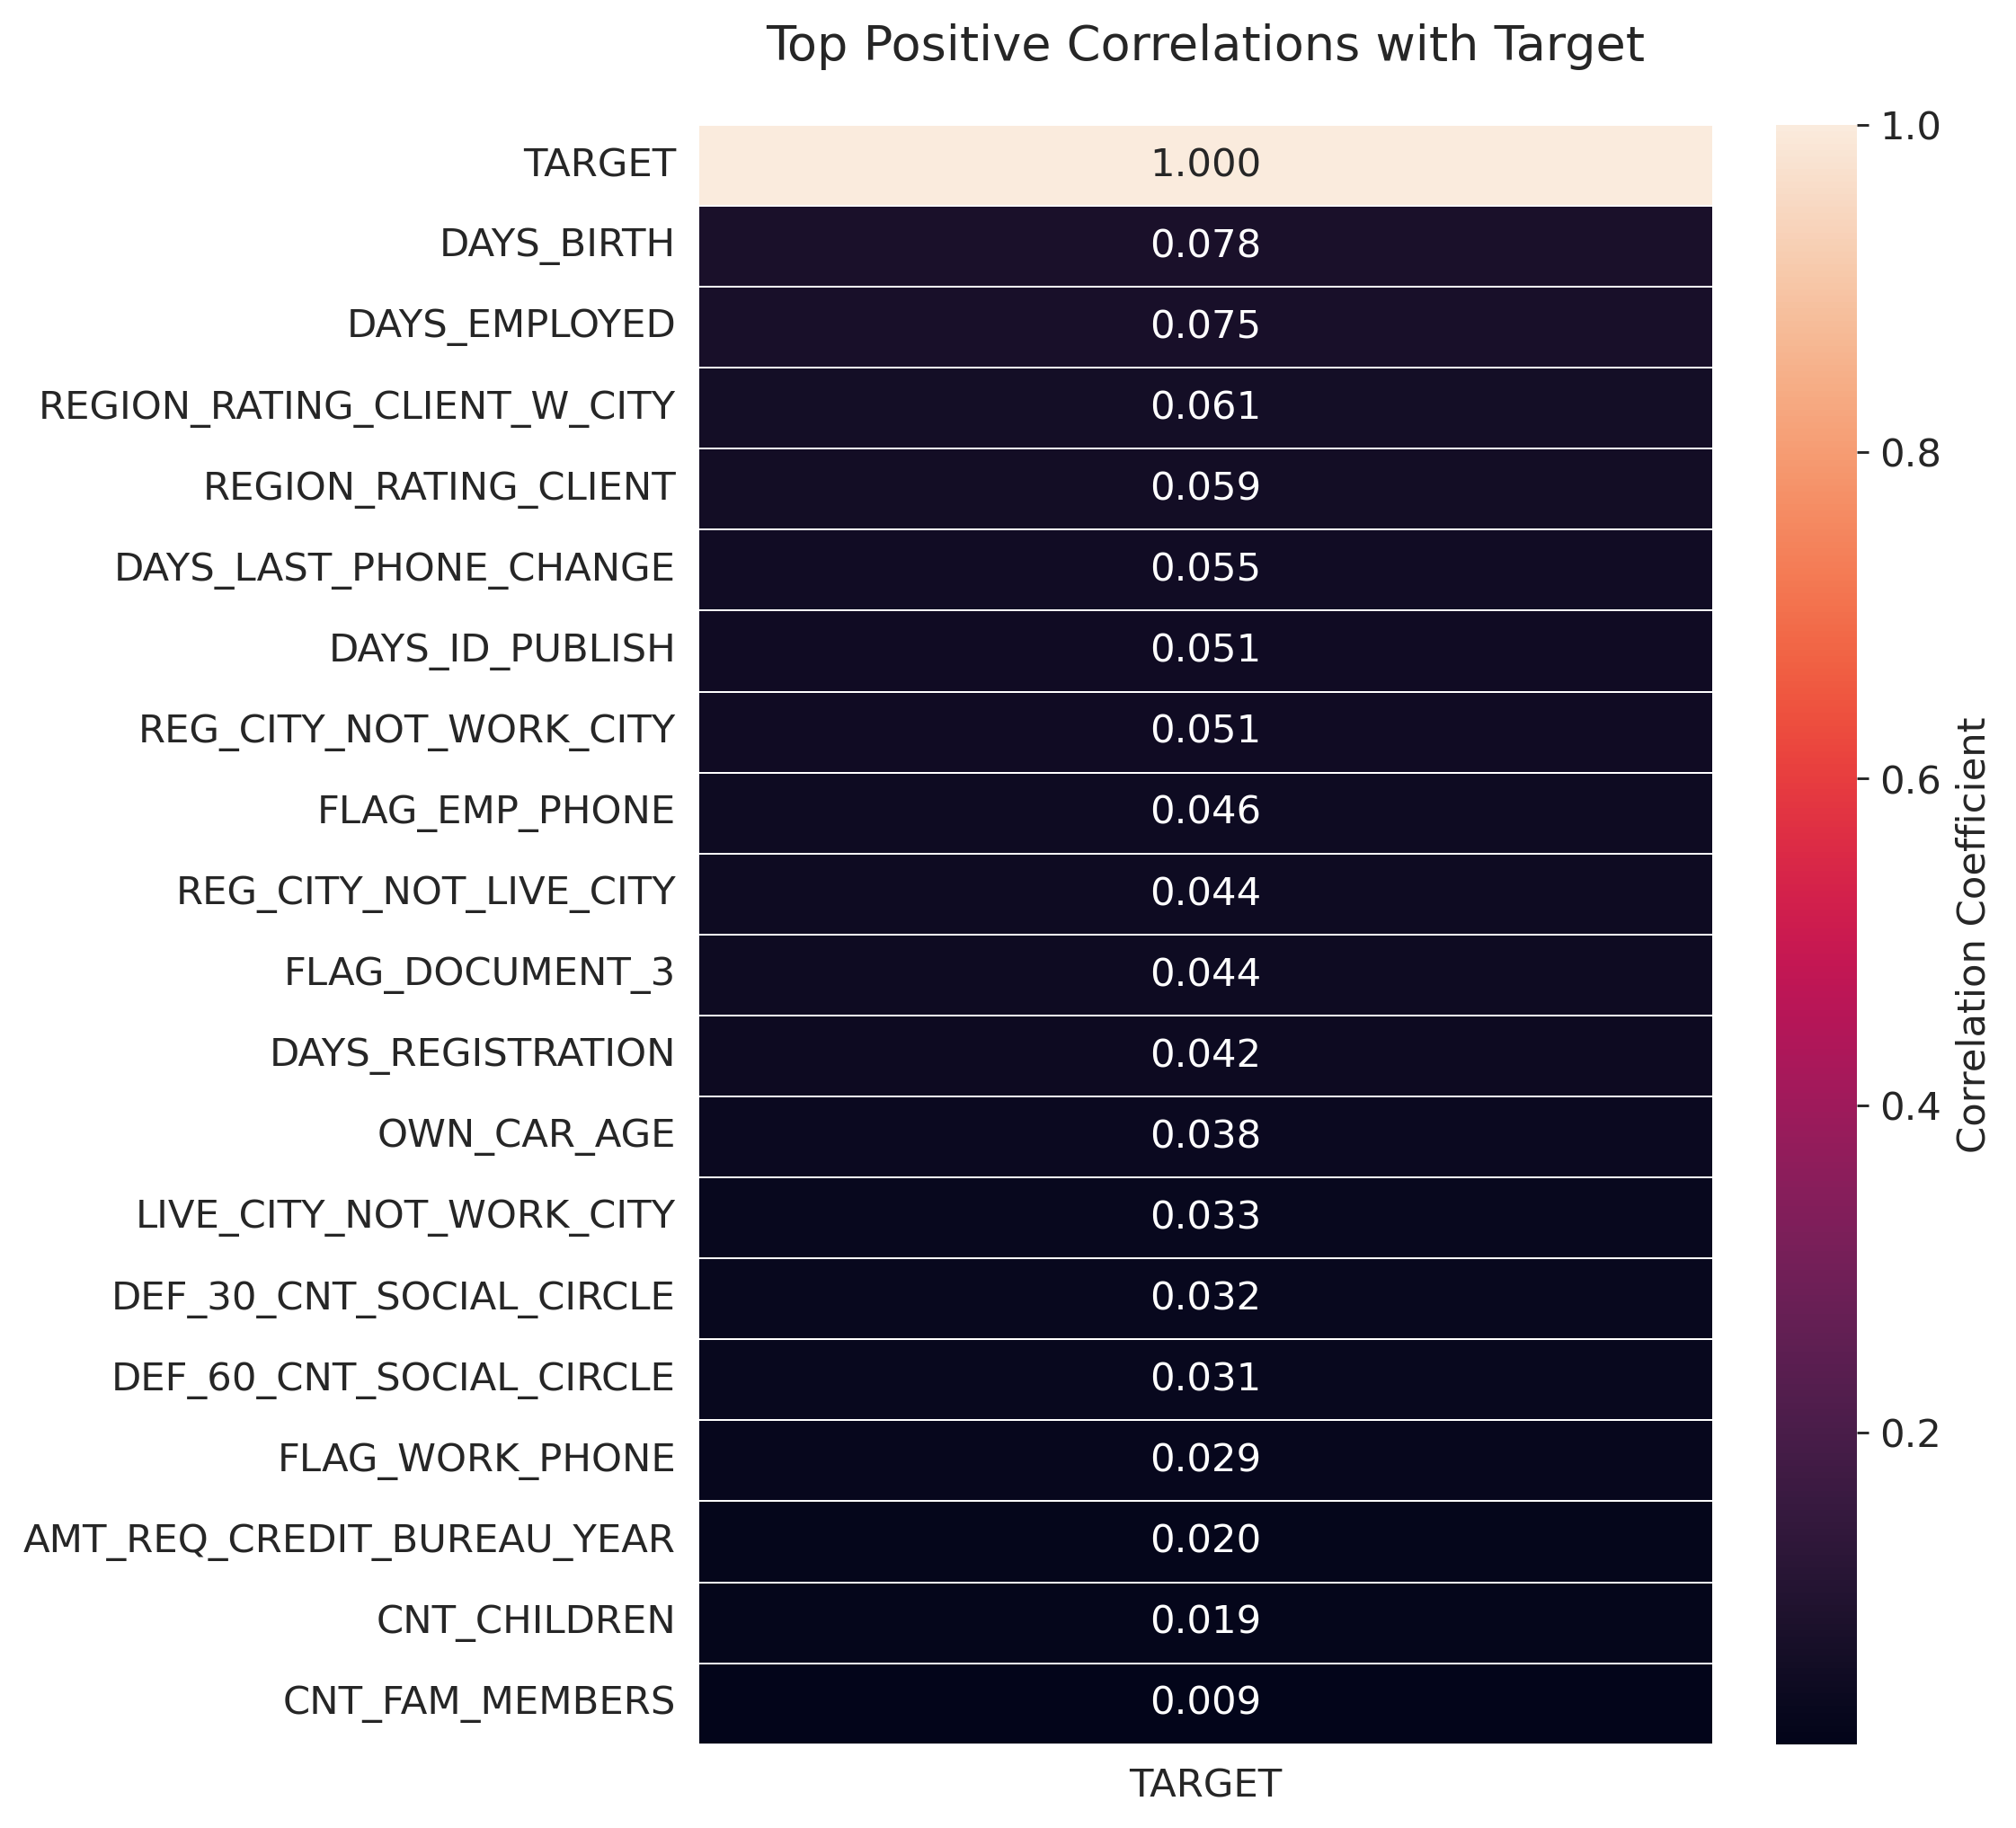

In [33]:
top_corr = train.corr(numeric_only=True)[["TARGET"]].sort_values(by="TARGET", ascending=False).head(20)

# 2. Set the figure size to prevent label crowding
plt.figure(figsize=(7,9 ), dpi=260)

# 3. Create the heatmap with improved styling
sns.heatmap(top_corr, annot=True, fmt=".3f", cmap="rocket", linewidths=0.5, linecolor='white', cbar_kws={'label': 'Correlation Coefficient'})

plt.title("Top Positive Correlations with Target", fontsize=15, pad=20)
plt.show()

#### Exploratory Data Analysis Summary

The exploratory analysis of the Home Credit Default Risk dataset reveals several important patterns related to borrower characteristics and credit risk.

#### 1. Demographic Characteristics

Age shows a clear relationship with default risk. Younger applicants tend to have a higher probability of default compared to older borrowers. This may be due to shorter credit histories, lower accumulated savings, and less stable income sources.

Employment duration also plays a role in borrower reliability. Applicants with longer employment histories generally demonstrate lower default risk, suggesting that employment stability is an important indicator of financial reliability.

---

#### 2. Financial Capacity

Income and credit amount distributions show significant skewness due to a small number of extreme outliers. Most borrowers fall within moderate income ranges, while very high incomes are rare.

Loan amount alone does not strongly differentiate defaulters from non-defaulters. However, the **credit-to-income ratio** provides a more meaningful measure of financial burden. Borrowers with larger loans relative to their income are more likely to experience repayment difficulties.

---

#### 3. External Credit Risk Indicators

External credit scores (EXT_SOURCE features) show one of the strongest relationships with default risk. Borrowers with lower external risk scores tend to default more frequently, while higher scores are associated with successful loan repayment.

These scores likely incorporate historical credit behavior and external financial information, making them highly predictive indicators of creditworthiness.

---

#### 4. Credit History

Analysis of bureau data indicates that most applicants have relatively few previous external loans, although a small number have extensive borrowing histories. Previous loan amount distributions are highly right-skewed, with most historical loans being relatively small.

These patterns suggest that borrowers often build credit histories gradually through smaller loans before accessing larger credit amounts.

---

#### 5. Repayment Behavior

Installment payment delay analysis shows that most borrowers make payments close to the scheduled due date. However, positive delays indicate late payments, which can signal financial distress and increased credit risk.

Repayment behavior features are particularly valuable because they capture actual borrower payment patterns rather than reported financial characteristics.

---

#### 6. Correlation Analysis

Correlation analysis shows that no single feature strongly explains default risk on its own. Instead, credit risk appears to be influenced by multiple interacting factors including age, employment stability, regional economic conditions, credit history, and financial burden.

This highlights the importance of combining multiple features and using advanced machine learning models to capture complex relationships within the data.

---

#### Key Risk Indicators Identified

The most important factors associated with default risk include:

- Lower external credit scores  
- Higher credit-to-income ratios  
- Younger borrower age  
- Shorter employment duration  
- Frequent credit bureau inquiries  
- Installment payment delays  

These findings provide valuable insights into borrower risk profiles and will guide the feature engineering and modeling stages of the project.

### 17. Feature Importance Candidates

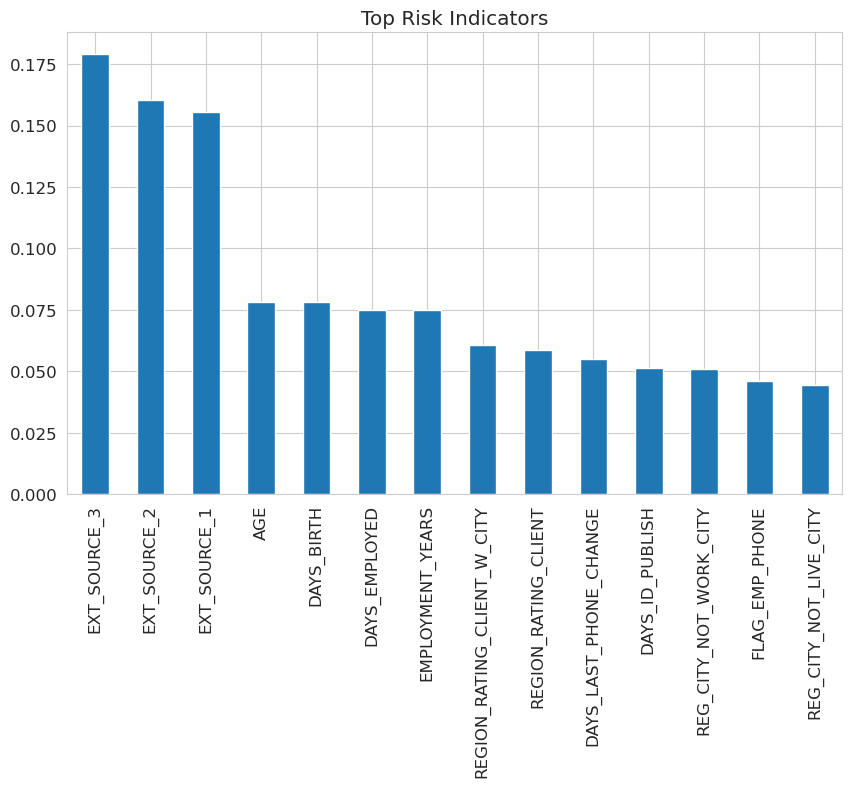

In [34]:
corr = train.corr(numeric_only=True)
top_corr = corr["TARGET"].abs().sort_values(ascending=False)[1:15]

top_corr.plot(kind="bar")

plt.title("Top Risk Indicators")
plt.show()

#### Top Risk Indicators

The bar chart summarizes the features that show the strongest association with loan default risk. Among these variables, the **external credit score features (EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3)** demonstrate the highest importance.

These external scores likely capture historical credit behavior from external financial institutions and therefore provide strong signals about borrower reliability.

Demographic variables such as **age (DAYS_BIRTH)** and **employment duration (DAYS_EMPLOYED / EMPLOYMENT_YEARS)** also appear as relevant indicators, suggesting that borrower stability and life stage influence credit risk.

Regional risk ratings (**REGION_RATING_CLIENT and REGION_RATING_CLIENT_W_CITY**) indicate that geographic economic conditions may also impact borrower repayment ability.

Other features such as **DAYS_LAST_PHONE_CHANGE** and **DAYS_ID_PUBLISH** may reflect behavioral or stability indicators, potentially capturing changes in personal information or financial activity.

Overall, the analysis suggests that default risk is influenced by a combination of:
- external credit history indicators
- borrower demographic characteristics
- employment stability
- geographic economic conditions
- behavioral indicators

### 18. Pairwise Risk Relationships

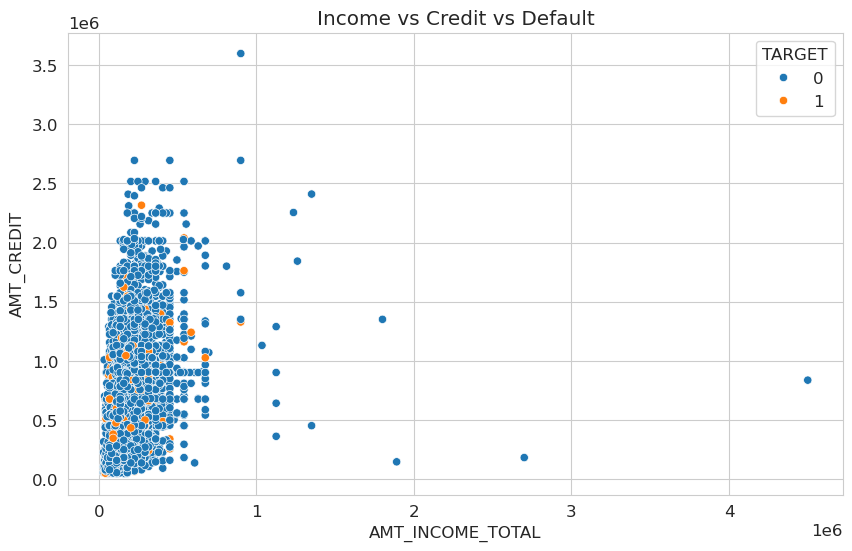

In [35]:
sns.scatterplot(
x="AMT_INCOME_TOTAL",
y="AMT_CREDIT",
hue="TARGET",
data=train.sample(10000)
)

plt.title("Income vs Credit vs Default")
plt.show()

#### Income, Credit Amount, and Default Risk

The scatter plot illustrates the relationship between applicant income, loan credit amount, and default status.

Most borrowers are concentrated in the lower to moderate income range, typically below 500,000. Within this group, credit amounts vary widely, indicating that borrowers with similar incomes may receive significantly different loan sizes.

Defaulters (orange points) appear more frequently among borrowers with relatively **high credit amounts compared to their income levels**. This suggests that the financial burden of large loans relative to income may contribute to repayment difficulties.

In contrast, borrowers with higher incomes generally show lower default occurrences, indicating greater financial capacity to manage loan repayments.

    The visualization highlights that **loan size alone does not determine default risk**. Instead, the relationship between credit amount and income appears to be more important.

    Borrowers who take loans that represent a large proportion of their income may face higher repayment pressure, increasing the likelihood of default.

### 19. Risk Heatmap

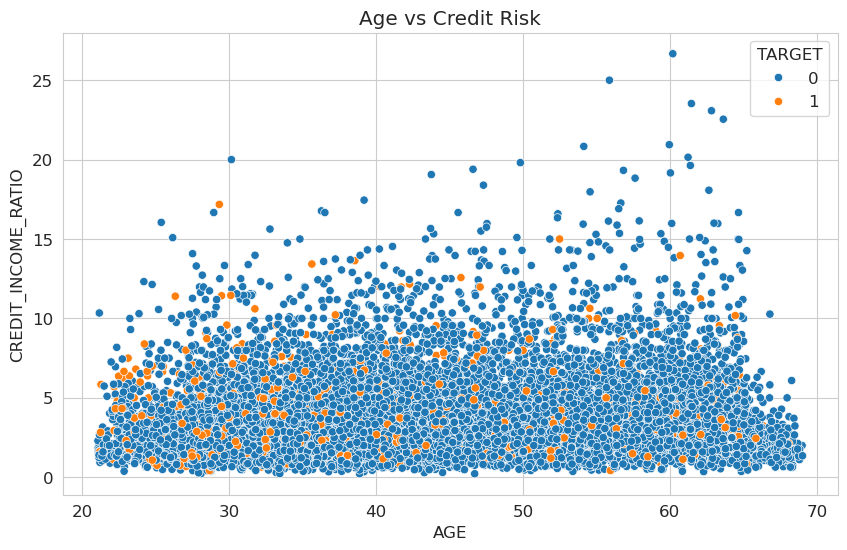

In [36]:
sns.scatterplot(
x="AGE",
y="CREDIT_INCOME_RATIO",
hue="TARGET",
data=train.sample(10000)
)

plt.title("Age vs Credit Risk")
plt.show()

#### Age, Credit Burden, and Default Risk

This visualization examines the relationship between borrower age, credit burden (measured by the credit-to-income ratio), and loan default status.

The scatter plot shows that borrowers across all age groups take loans with varying credit-to-income ratios. However, higher ratios indicate a larger financial burden relative to income.

Default cases appear more frequently among borrowers with **higher credit-to-income ratios**, suggesting that excessive loan size relative to income increases financial stress and repayment difficulty.

Younger borrowers also appear slightly more represented among higher-risk cases, which may reflect shorter credit histories, lower accumulated savings, and less stable income sources.

    Borrowers with higher credit-to-income ratios tend to show more default cases across all age groups, indicating that financial burden relative to income is a key driver of credit risk.

#### 20. Key Risk Indicators Identified

1. High credit-to-income ratio increases default risk
2. Younger applicants show slightly higher default probability
3. Lower income groups show higher default rates
4. Short employment duration increases risk
5. External credit scores are strong predictors
6. Late installment payments indicate financial distress
7. Customers with many previous loans show higher risk

### 21. Loan Burden Analysis

In [37]:
train["ANNUITY_INCOME_RATIO"] = train["AMT_ANNUITY"] / train["AMT_INCOME_TOTAL"]

train["CREDIT_TERM"] = train["AMT_ANNUITY"] / train["AMT_CREDIT"]

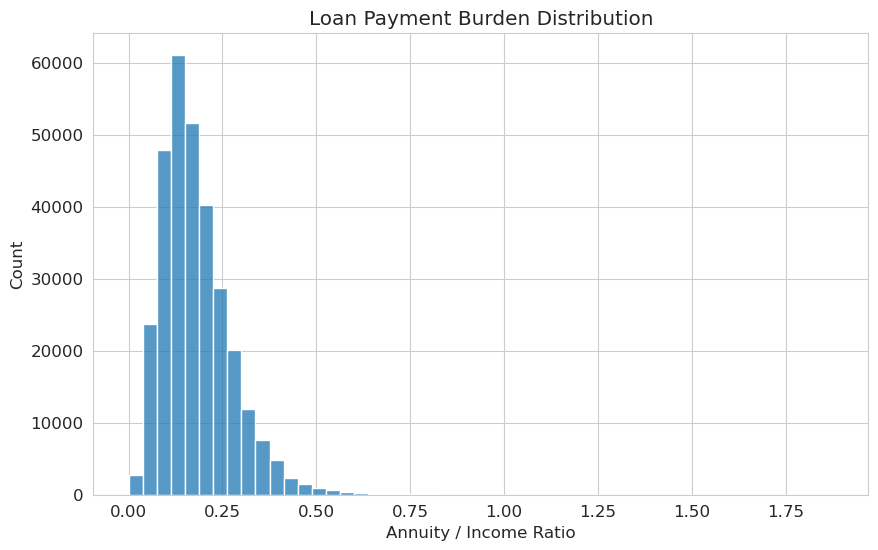

In [38]:
sns.histplot(train["ANNUITY_INCOME_RATIO"], bins=50)

plt.title("Loan Payment Burden Distribution")
plt.xlabel("Annuity / Income Ratio")
plt.show()

#### Loan Payment Burden Distribution

The annuity-to-income ratio measures the proportion of a borrower’s income that is required to service loan payments. This metric reflects the financial burden imposed by loan repayments.

The distribution shows that most borrowers have annuity-to-income ratios between **0.05 and 0.25**, meaning that their loan payments account for approximately **5% to 25% of their total income**.

The distribution is right-skewed, with a small number of borrowers exhibiting significantly higher ratios. These cases represent borrowers whose loan repayments consume a large portion of their income, potentially increasing their financial vulnerability.

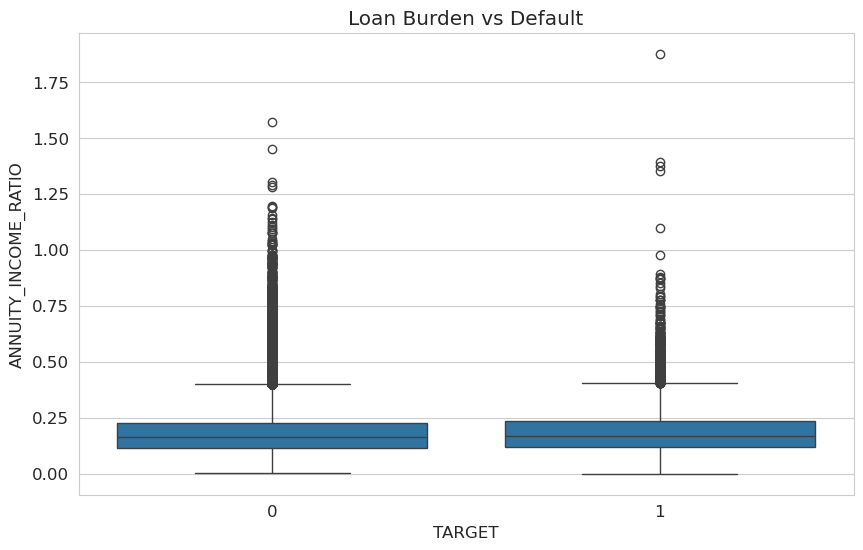

In [39]:
sns.boxplot(x="TARGET", y="ANNUITY_INCOME_RATIO", data=train)

plt.title("Loan Burden vs Default")
plt.show()

#### Loan Burden vs Default Risk

This boxplot compares the distribution of the annuity-to-income ratio between borrowers who defaulted (TARGET = 1) and those who successfully repaid their loans (TARGET = 0).

The annuity-to-income ratio measures the proportion of income required to service loan repayments. Higher values indicate greater repayment burden.

The distribution shows that defaulters tend to have slightly higher annuity-to-income ratios compared to non-defaulters. This suggests that borrowers whose loan repayments consume a larger share of their income may face greater financial pressure and increased probability of default.

Although the distributions overlap significantly, the presence of more extreme values among defaulters indicates that excessive repayment burden can contribute to credit risk.

### 22. External Score Interaction Analysis

In [40]:
train["EXT_SOURCE_MEAN"] = train[
["EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3"]
].mean(axis=1)

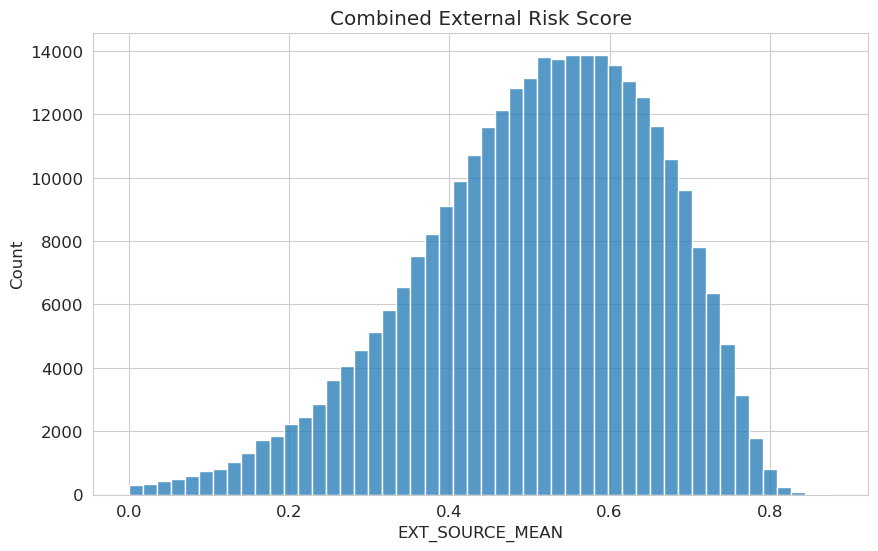

In [41]:
sns.histplot(train["EXT_SOURCE_MEAN"], bins=50)

plt.title("Combined External Risk Score")
plt.show()

#### Combined External Risk Score Analysis

To better capture borrower creditworthiness, the three external risk score features (EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3) were combined by computing their mean value. This aggregated feature provides a more robust estimate of external credit risk.

The distribution of the combined external score shows that most applicants fall within the range of approximately **0.4 to 0.7**, indicating moderate levels of creditworthiness according to external financial sources.

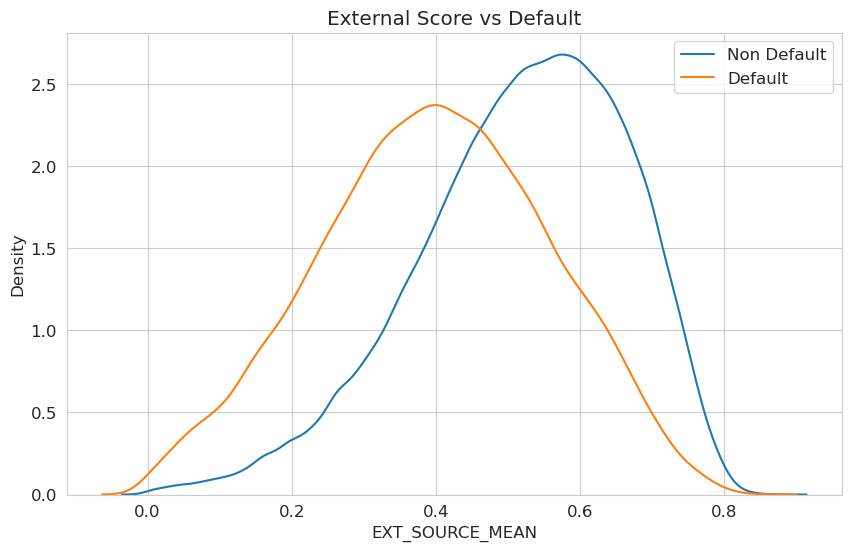

In [42]:
sns.kdeplot(
train.loc[train.TARGET==0,"EXT_SOURCE_MEAN"],
label="Non Default"
)

sns.kdeplot(
train.loc[train.TARGET==1,"EXT_SOURCE_MEAN"],
label="Default"
)

plt.legend()
plt.title("External Score vs Default")
plt.show()

#### External Risk Score and Default Probability

The density plot comparing defaulters and non-defaulters shows a clear separation between the two groups.

Borrowers who default tend to have **lower external risk scores**, while borrowers who successfully repay their loans generally have **higher scores**. The shift in the distribution indicates that external risk scores capture important information about borrower creditworthiness and repayment behavior.

### 23. Credit Exposure Risk

In [43]:
train["CREDIT_GOODS_RATIO"] = (
train["AMT_CREDIT"] / train["AMT_GOODS_PRICE"]
)

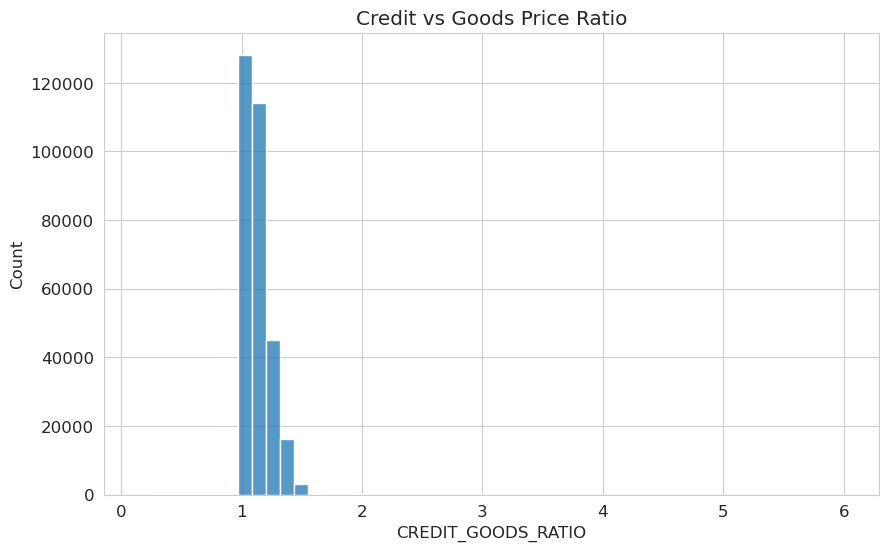

In [44]:
sns.histplot(train["CREDIT_GOODS_RATIO"], bins=50)

plt.title("Credit vs Goods Price Ratio")
plt.show()

#### Credit to Goods Price Ratio

The credit-to-goods price ratio measures the relationship between the loan amount and the value of the goods or assets being financed. A ratio close to **1** indicates that the loan amount closely matches the price of the goods being purchased.

The distribution shows that most borrowers have ratios slightly above **1**, suggesting that loan amounts typically cover the majority of the asset value and may include additional costs such as fees, insurance, or related expenses.

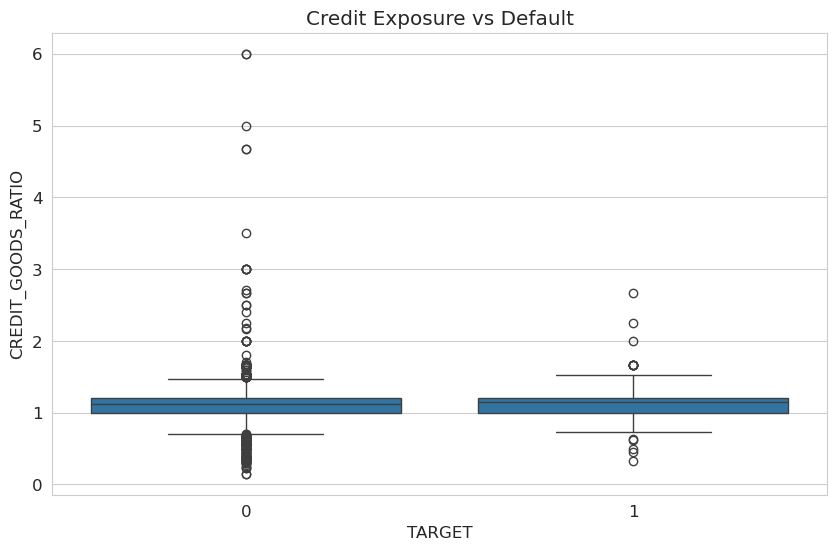

In [45]:
sns.boxplot(
x="TARGET",
y="CREDIT_GOODS_RATIO",
data=train
)

plt.title("Credit Exposure vs Default")
plt.show()

#### Credit Exposure and Default Risk

The boxplot comparing credit-to-goods ratios across default groups shows that the distributions for defaulters and non-defaulters are relatively similar.

While defaulters exhibit slightly higher ratios in some cases, the overlap between the groups suggests that the credit-to-goods ratio alone is not a strong predictor of default risk.

### 24. Delinquency Risk Patterns

In [46]:
installments["PAYMENT_DELAY"] = (
installments["DAYS_ENTRY_PAYMENT"] -
installments["DAYS_INSTALMENT"]
)

installments["LATE_PAYMENT"] = (
installments["PAYMENT_DELAY"] > 0
).astype(int)

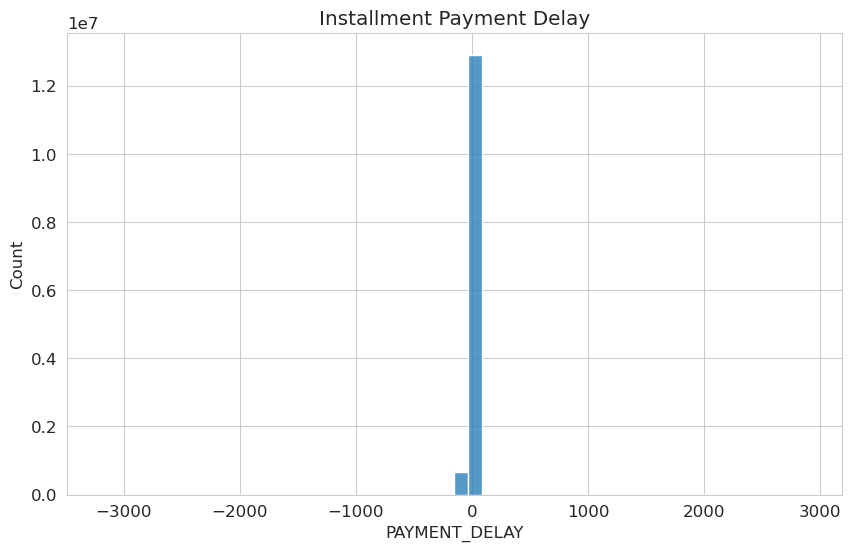

In [47]:
sns.histplot(installments["PAYMENT_DELAY"], bins=50)

plt.title("Installment Payment Delay")
plt.show()

#### Installment Payment Delay

Payment delay is calculated as the difference between the actual payment date and the scheduled installment date. Negative values indicate payments made before the due date, while positive values represent late payments.

The distribution shows a strong concentration around zero, suggesting that most borrowers make payments close to the scheduled due date. However, the presence of both early and delayed payments indicates variability in borrower repayment behavior.

Extreme delay values appear in the dataset, which may represent exceptional payment circumstances or data recording artifacts.


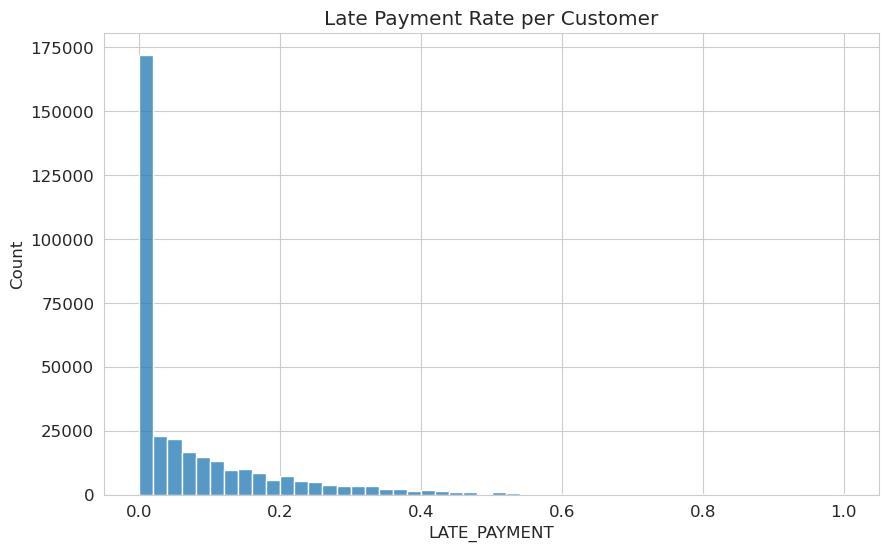

In [48]:
late_rate = installments.groupby("SK_ID_CURR")["LATE_PAYMENT"].mean()

sns.histplot(late_rate, bins=50)

plt.title("Late Payment Rate per Customer")
plt.show()

#### Late Payment Rate per Customer

The late payment rate measures the proportion of installments that were paid after the scheduled due date for each borrower.

The distribution shows that the majority of borrowers have very low late payment rates, indicating that most customers generally make payments on time. However, a smaller subset of borrowers exhibits higher late payment frequencies, suggesting persistent repayment difficulties.

### 25. Multi-Feature Risk Segmentation

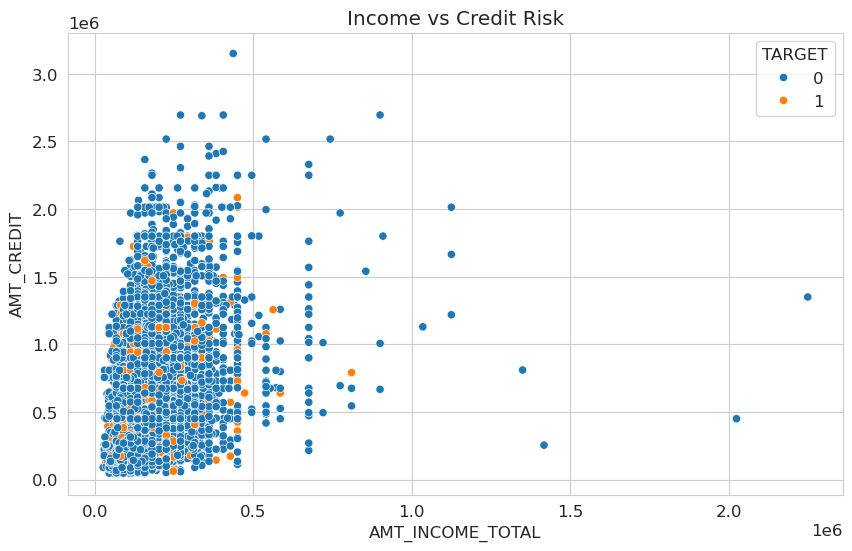

In [49]:
sns.scatterplot(
x="AMT_INCOME_TOTAL",
y="AMT_CREDIT",
hue="TARGET",
data=train.sample(10000)
)

plt.title("Income vs Credit Risk")
plt.show()

#### Income vs Credit Risk

This scatter plot illustrates the relationship between borrower income, loan credit amount, and default status.

Most applicants are concentrated in the lower to moderate income range, typically below 500,000. Within this range, loan credit amounts vary significantly, indicating that borrowers with similar income levels may receive different loan sizes.

Default cases appear more frequently among borrowers whose loan amounts are relatively large compared to their income levels. This suggests that excessive loan exposure relative to financial capacity may increase the probability of default.

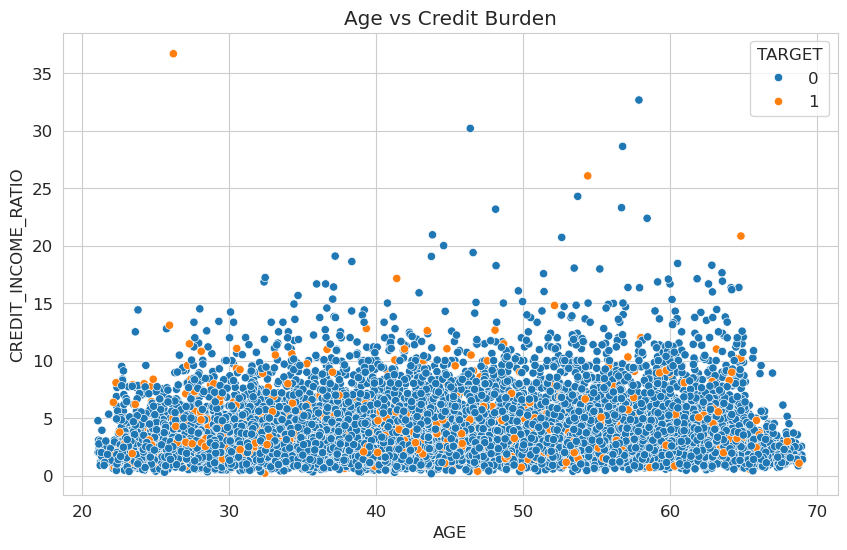

In [50]:
sns.scatterplot(
x="AGE",
y="CREDIT_INCOME_RATIO",
hue="TARGET",
data=train.sample(10000)
)

plt.title("Age vs Credit Burden")
plt.show()

#### Age vs Credit Burden

This visualization examines the relationship between borrower age and credit burden, measured by the credit-to-income ratio.

The plot shows that borrowers across all age groups experience varying levels of financial burden. However, higher credit-to-income ratios indicate greater financial pressure, as loan obligations represent a larger share of borrower income.

Default cases appear across multiple age groups but tend to be more common among borrowers with higher credit burdens. This indicates that financial strain may contribute to repayment difficulties regardless of borrower age.

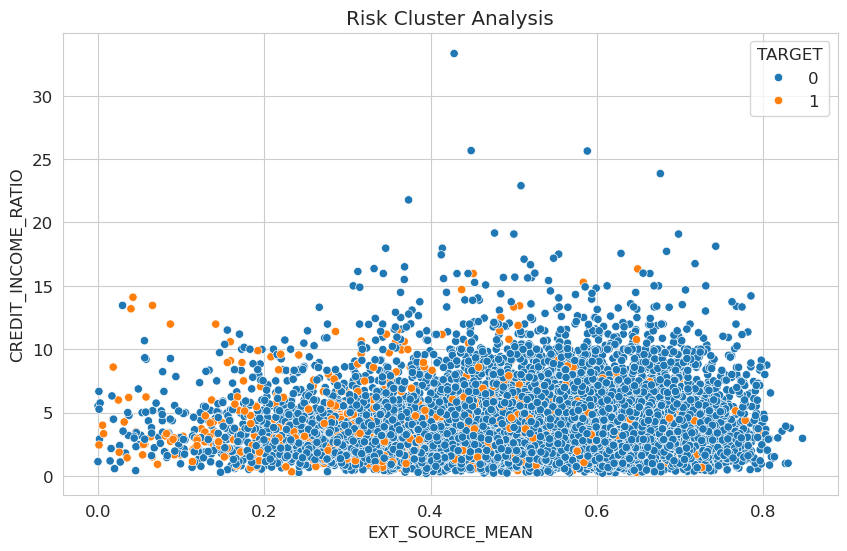

In [51]:
sns.scatterplot(
x="EXT_SOURCE_MEAN",
y="CREDIT_INCOME_RATIO",
hue="TARGET",
data=train.sample(10000)
)

plt.title("Risk Cluster Analysis")
plt.show()

#### Risk Cluster Analysis

This plot combines external credit risk scores with borrower financial burden to identify potential risk clusters.

Borrowers with **higher external credit scores** tend to show lower default rates, while borrowers with **lower external scores** appear more frequently among default cases.

Additionally, borrowers with both **low external credit scores and high credit-to-income ratios** form a cluster that represents elevated credit risk. These individuals combine weaker historical credit performance with higher financial burden, increasing the likelihood of repayment difficulties.

## Key Credit Risk Indicators Discovered

Major predictors of loan default include:

• Low external credit scores  
• High credit-to-income ratio  
• High loan payment burden  
• Frequent late installment payments  
• Short employment history  
• Younger applicant age  

These features will be strong candidates for
machine learning models in the next phase.